# 1. Adversarial Attack

In [1]:
# FGSM 공격 함수 정의
def fgsm_attack(model, x, y, epsilon, criterion):
    x.requires_grad = True
    output = model(x)
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()
    x_grad = x.grad.data.sign()
    x_adv = x + epsilon * x_grad
    return x_adv.detach()

In [2]:
# PGD 공격 함수
def pgd_attack(model, x, y, rho=0.1, epsilon=0.01, iters=10, criterion=None):
    x_adv = x.clone().detach().requires_grad_(True)
    x_orig = x.clone().detach()
    for _ in range(iters):
        output = model(x_adv)
        loss = criterion(output, y)
        model.zero_grad()
        loss.backward()
        grad = x_adv.grad.sign()
        x_adv = x_adv + epsilon * grad
        x_adv = torch.clamp(x_adv, x_orig - rho, x_orig + rho)
        x_adv = x_adv.detach().requires_grad_(True)
    return x_adv.detach()

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset

"""
seed 설정
"""
# 1. 데이터 생성
X, y = make_classification(n_samples=10000, n_features=20, n_informative=15, n_classes=2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.int64)

# 2. 데이터 분할 (train:val:test = 64:16:20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# 3. 정규화 (train 기준으로 fit)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Tensor 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# 데이터 로더 정의
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=128)



ModuleNotFoundError: No module named 'torch'

In [ ]:
# 4. 모델 정의
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN(20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 학습 루프
best_val_acc = 0
best_model = None
train_losses, val_losses, val_accuracies = [], [], []
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            val_loss += criterion(output, yb).item()
            val_preds.extend(torch.argmax(output, dim=1).cpu().numpy())
            val_labels.extend(yb.cpu().numpy())
    acc = accuracy_score(val_labels, val_preds)
    val_accuracies.append(acc)
    val_losses.append(val_loss / len(val_loader))

    if acc > best_val_acc:
        best_val_acc = acc
        best_model = model.state_dict()
        best_epoch = epoch

# 5. 테스트 정확도 평가
model.load_state_dict(best_model)
model.eval()
test_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        output = model(xb)
        test_preds.extend(torch.argmax(output, dim=1).cpu().numpy())
test_acc = accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9675


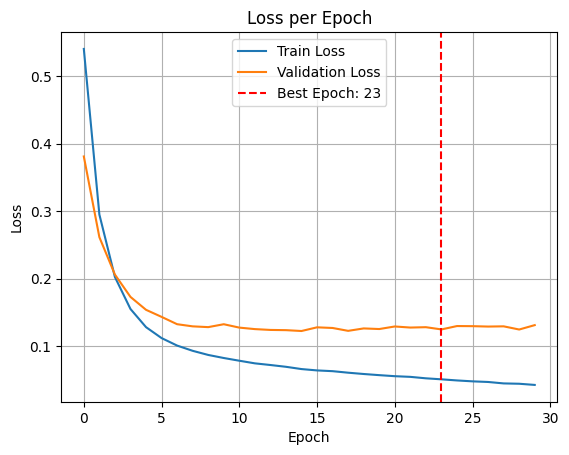

In [ ]:
# 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


- validation accuracy를 기준으로 best model 설정

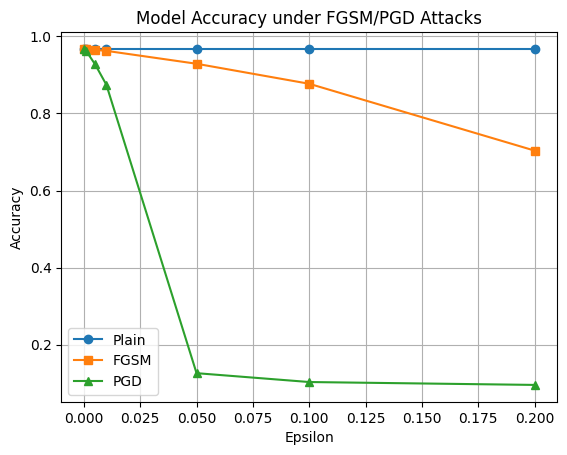

In [ ]:
import matplotlib.pyplot as plt

# 평가용 epsilon 리스트
epsilons = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2]

acc_plain_list = []
acc_fgsm_list = []
acc_pgd_list = []

model.load_state_dict(best_model)
model.eval()

for eps in epsilons:
    correct_plain = 0
    correct_fgsm = 0
    correct_pgd = 0
    total = 0

    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)

        # (1) plain
        with torch.no_grad():
            pred_plain = model(xb).argmax(dim=1)

        # (2) fgsm
        xb_fgsm = fgsm_attack(model, xb.clone(), yb, epsilon=eps, criterion=criterion)
        with torch.no_grad():
            pred_fgsm = model(xb_fgsm).argmax(dim=1)

        # (3) pgd
        xb_pgd = pgd_attack(model, xb.clone(), yb, rho=0.5, epsilon=eps, iters=10, criterion=criterion)
        with torch.no_grad():
            pred_pgd = model(xb_pgd).argmax(dim=1)

        correct_plain += (pred_plain == yb).sum().item()
        correct_fgsm += (pred_fgsm == yb).sum().item()
        correct_pgd += (pred_pgd == yb).sum().item()
        total += yb.size(0)

    acc_plain_list.append(correct_plain / total)
    acc_fgsm_list.append(correct_fgsm / total)
    acc_pgd_list.append(correct_pgd / total)

# 시각화
plt.plot(epsilons, acc_plain_list, marker='o', label='Plain')
plt.plot(epsilons, acc_fgsm_list, marker='s', label='FGSM')
plt.plot(epsilons, acc_pgd_list, marker='^', label='PGD')
plt.title("Model Accuracy under FGSM/PGD Attacks")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


- X축 (Epsilon): 공격 강도. ε가 클수록 입력 perturbation이 큼
- Y축 (Accuracy): 공격 후 모델이 예측을 맞춘 비율
- 파란색 (Plain)
  - FGSM 또는 PGD 공격을 적용하지 않은 원본(clean) 데이터에 대한 정확도 (조금전 우리가 살펴봤던 Test Accuracy: 0.9620, 기준선)
- 주황색 (FGSM Attack Accuracy)
  - FGSM 공격을 받은 경우 정확도가 ε 증가에 따라 점진적으로 하락
  - ε = 0.2일 때도 약 72% 정확도 유지 => FGSM은 비교적 약한 공격
- 초록색 (PGD Attack Accuracy)
  - ε = 0.02 이후부터 정확도가 급격히 하락
  - ε ≥ 0.05에서는 정확도가 15% 이하로 추락 => PGD는 매우 강력한 반복 공격

- 이처럼, 더 좋은 공격력을 갖는 방법론을 제안하는 식으로 연구가 이루어 짐.

# 2. Adversarial Defense
- (1) Adversarial Attack FGSM (이때, Epsilon을 고정)
  - (1) no denfense model
  - (2) fgsm-defense model
  - (3) pgd-defense model
- (2) Adversarial Attack PGD (이때, Epsilon을 고정)
  - (1) no denfense model
  - (2) fgsm-defense model
  - (3) pgd-defense model


In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# FGSM attack
def fgsm_attack(model, x, y, epsilon, criterion):
    x.requires_grad = True
    output = model(x)
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()
    grad = x.grad.sign()
    return (x + epsilon * grad).detach()

# PGD attack
def pgd_attack(model, x, y, rho=0.1, epsilon=0.01, iters=10, criterion=None):
    x_adv = x.clone().detach().requires_grad_(True)
    x_orig = x.clone().detach()
    for _ in range(iters):
        output = model(x_adv)
        loss = criterion(output, y)
        model.zero_grad()
        loss.backward()
        grad = x_adv.grad.sign()
        x_adv = x_adv + epsilon * grad
        x_adv = torch.clamp(x_adv, x_orig - rho, x_orig + rho)
        x_adv = x_adv.detach().requires_grad_(True)
    return x_adv.detach()


# Evaluation under attack
def evaluate_under_attack(model, test_loader, epsilons, criterion, attack_fn, rho=0.5, iters=10):
    model.eval()
    acc_list = []
    for eps in epsilons:
        correct, total = 0, 0
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            if eps > 0:
                if attack_fn == "fgsm":
                    xb = fgsm_attack(model, xb.clone(), yb, epsilon=eps, criterion=criterion)
                elif attack_fn == "pgd":
                    xb = pgd_attack(model, xb.clone(), yb, rho=rho, epsilon=eps, iters=iters, criterion=criterion)
            output = model(xb)
            preds = output.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
        acc_list.append(correct / total)
    return acc_list

In [ ]:
# General training function
def train_model(train_loader, input_dim=20, attack_type=None, eps=0.1, rho=0.1, iters=10, num_epochs=10):
    model = SimpleNN(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    alpha = 0.7  # clean loss weight

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            # clean loss
            output_clean = model(xb)
            loss_clean = criterion(output_clean, yb)

            # adv loss
            if attack_type == 'fgsm':
                xb_adv = fgsm_attack(model, xb.clone(), yb, epsilon=eps, criterion=criterion)
                output_adv = model(xb_adv)
                loss_adv = criterion(output_adv, yb)
                loss = alpha * loss_clean + (1 - alpha) * loss_adv

            elif attack_type == 'pgd':
                xb_adv = pgd_attack(model, xb.clone(), yb, rho=rho, epsilon=eps, iters=iters, criterion=criterion)
                output_adv = model(xb_adv)
                loss_adv = criterion(output_adv, yb)
                loss = alpha * loss_clean + (1 - alpha) * loss_adv

            else:  # no defense
                loss = loss_clean

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model


In [ ]:
# Train each model
model_plain = train_model(train_loader, attack_type=None)
model_fgsm = train_model(train_loader, attack_type='fgsm', eps=0.1)
model_pgd = train_model(train_loader, attack_type='pgd', rho=0.5, eps=0.1, iters=10)

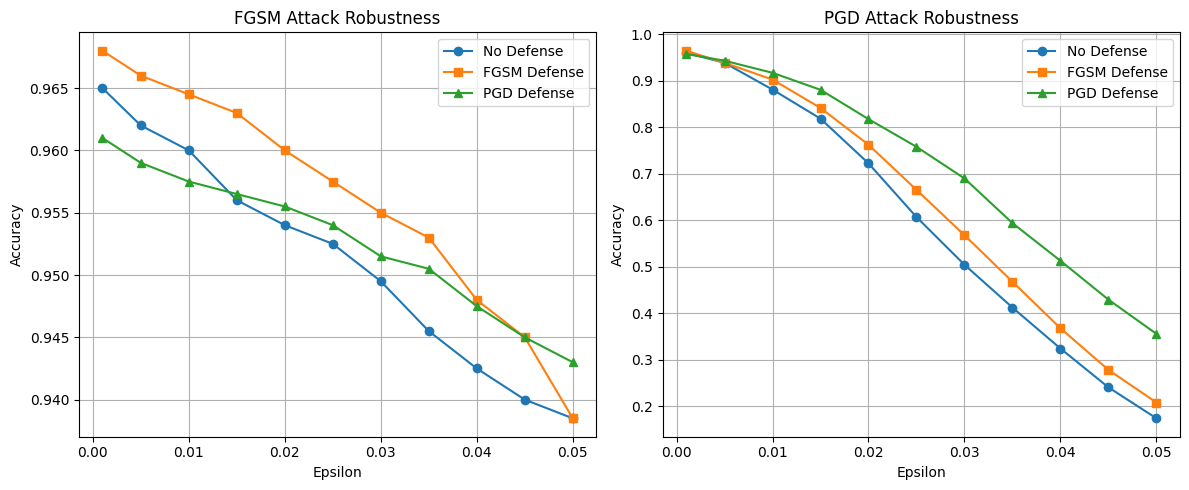

In [ ]:
# Run experiments
epsilons = [0.001, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
criterion = nn.CrossEntropyLoss()

# Evaluate under FGSM attack
acc_fgsm_plain = evaluate_under_attack(model_plain, test_loader, epsilons, criterion, attack_fn="fgsm")
acc_fgsm_fgsm = evaluate_under_attack(model_fgsm, test_loader, epsilons, criterion, attack_fn="fgsm")
acc_fgsm_pgd  = evaluate_under_attack(model_pgd, test_loader, epsilons, criterion, attack_fn="fgsm")

# Evaluate under PGD attack
acc_pgd_plain = evaluate_under_attack(model_plain, test_loader, epsilons, criterion, attack_fn="pgd")
acc_pgd_fgsm  = evaluate_under_attack(model_fgsm, test_loader, epsilons, criterion, attack_fn="pgd")
acc_pgd_pgd   = evaluate_under_attack(model_pgd, test_loader, epsilons, criterion, attack_fn="pgd")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epsilons, acc_fgsm_plain, marker='o', label='No Defense')
plt.plot(epsilons, acc_fgsm_fgsm, marker='s', label='FGSM Defense')
plt.plot(epsilons, acc_fgsm_pgd, marker='^', label='PGD Defense')
plt.title("FGSM Attack Robustness")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epsilons, acc_pgd_plain, marker='o', label='No Defense')
plt.plot(epsilons, acc_pgd_fgsm, marker='s', label='FGSM Defense')
plt.plot(epsilons, acc_pgd_pgd, marker='^', label='PGD Defense')
plt.title("PGD Attack Robustness")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 실험 결과 해석
- (왼쪽) FGSM 방법론을 기반으로 epsilon을 증가시키며 Attack 했을 때 방어 성능:
  - No Defense model: ε 증가에 따라 빠르게 정확도 감소
  - FGSM Defense model: ε 증가에 따라 방어성능은 대체로 FGSM이 좋았다.
  - PGD Defense model:  단, epsilon이 커지면 커질수록 PGD 성능이 더 좋은 것으로 보인다. 즉, 더 강력한 공격은 PGD 기반 방어모델이 더 효과적인 것으로 보인다.
- (오른쪽) PGD 방법론을 기반으로 epsilon을 증가시키며 Attack 했을 때 방어 성능:
  - No Defense model: ε 증가에 따라 빠르게 정확도 감소
  - FGSM Defense model: PGD공격에 대한 방어성능은 대체로 FGSM 보다 "PGD"가 좋았다.
  - PGD Defense model:  PGD공격에 대한 방어성능은 "PGD"가 안정적으로 좋은 성능을 보인다.

- 종합적으로, 공격이 강력해질수록, 더 강한 adversarial training 기반 방어(PGD)가 효과적이며, 공격 유형과 강도에 맞는 방어 전략을 설계하는 것이 중요함,

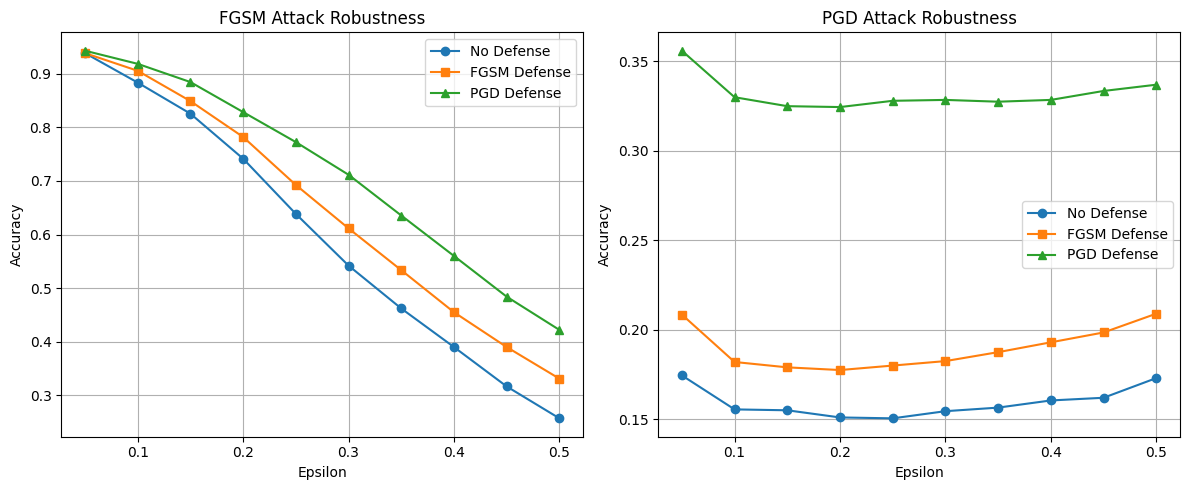

In [ ]:
# Run experiments
epsilons = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
criterion = nn.CrossEntropyLoss()

# Evaluate under FGSM attack
acc_fgsm_plain = evaluate_under_attack(model_plain, test_loader, epsilons, criterion, attack_fn="fgsm")
acc_fgsm_fgsm = evaluate_under_attack(model_fgsm, test_loader, epsilons, criterion, attack_fn="fgsm")
acc_fgsm_pgd  = evaluate_under_attack(model_pgd, test_loader, epsilons, criterion, attack_fn="fgsm")

# Evaluate under PGD attack
acc_pgd_plain = evaluate_under_attack(model_plain, test_loader, epsilons, criterion, attack_fn="pgd")
acc_pgd_fgsm  = evaluate_under_attack(model_fgsm, test_loader, epsilons, criterion, attack_fn="pgd")
acc_pgd_pgd   = evaluate_under_attack(model_pgd, test_loader, epsilons, criterion, attack_fn="pgd")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epsilons, acc_fgsm_plain, marker='o', label='No Defense')
plt.plot(epsilons, acc_fgsm_fgsm, marker='s', label='FGSM Defense')
plt.plot(epsilons, acc_fgsm_pgd, marker='^', label='PGD Defense')
plt.title("FGSM Attack Robustness")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epsilons, acc_pgd_plain, marker='o', label='No Defense')
plt.plot(epsilons, acc_pgd_fgsm, marker='s', label='FGSM Defense')
plt.plot(epsilons, acc_pgd_pgd, marker='^', label='PGD Defense')
plt.title("PGD Attack Robustness")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


- 추가적으로 실험해볼 것 (1)
  - (1) Adversarial Attack FGSM
    - (1) no denfense model (이때, Epsilon을 고정 => 변경)
    - (2) fgsm-defense model (이때, Epsilon을 고정 => 변경)
    - (3) pgd-defense model (이때, Epsilon을 고정 => 변경)
  - (2) Adversarial Attack PGD
    - (1) no denfense model (이때, Epsilon을 고정고정 => 변경)
    - (2) fgsm-defense model (이때, Epsilon을 고정고정 => 변경)
    - (3) pgd-defense model (이때, Epsilon을 고정고정 => 변경)

- 추가적으로 실험해볼 것 (2)
  - 본 실험 방식을 regression version으로 변경하여 실험해볼 것
  - FGSM/PGD는 주로 분류에서 다뤄졌지만, regression setting에서도 충분히 실험 가치 있음
  - 예: 혈압(의료) 예측, 불량률(제조) 예측 등에서 예측값 왜곡 정도(MAE, RMSE 변화) 확인 가능
  - 특히 adversarial training for regression은 연구적으로도 비교적 적게 다뤄져 있음 => 기여 가능